### Importing the dataset

In [ ]:
import pandas as pd
df=pd.read_csv('train_v9rqX0R.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


Handling null values

In [ ]:
mean = df['Item_Weight'].mean()
df['Item_Weight'].fillna(mean, inplace=True)

mode = df['Outlet_Size'].mode()[0]
df['Outlet_Size'].fillna(mode, inplace=True)

df.isnull().sum()

/tmp/ipykernel_405/3248241118.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(mean, inplace=True)
/tmp/ipykernel_405/3248241118.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [ ]:
df.shape

(8523, 12)

#Mapping the catergorical values to numerical values

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Item_Fat_Content']=le.fit_transform(df['Item_Fat_Content'])
df['Item_Type']=le.fit_transform(df['Item_Type'])
df['Outlet_Size']=le.fit_transform(df['Outlet_Size'])
df['Outlet_Location_Type']=le.fit_transform(df['Outlet_Location_Type'])
df['Outlet_Type']=le.fit_transform(df['Outlet_Type'])
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,1,0.016047,4,249.8092,OUT049,1999,1,0,1,3735.1380
1,DRC01,5.92,2,0.019278,14,48.2692,OUT018,2009,1,2,2,443.4228
2,FDN15,17.50,1,0.016760,10,141.6180,OUT049,1999,1,0,1,2097.2700
3,FDX07,19.20,2,0.000000,6,182.0950,OUT010,1998,1,2,0,732.3800
4,NCD19,8.93,1,0.000000,9,53.8614,OUT013,1987,0,2,1,994.7052


In [ ]:
df.drop(['Item_Identifier','Outlet_Identifier'], axis = 1, inplace = True) #Removing irrelevant columns
df.shape

(8523, 10)

### Train Test Split & Model Training

In [ ]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size = 0.2, random_state = 0)

x_train = train.drop('Item_Outlet_Sales', axis = 1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales', axis = 1)
y_test = test['Item_Outlet_Sales']

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error. accuracy_score
from math import sqrt
from 

model = KNeighborsRegressor(n_neighbors = 5)
model.fit(x_train, y_train) #Fit model
pred = model.predict(x_test) #Predict model on test set

error = sqrt(mean_squared_error(y_test, pred)) #Calculate error
error

acc = accuracy_score(y_test, pred)  # Calculate accuracy
print(f'Accuracy (k=5): {acc:.4f}')

1307.410900981443

In [ ]:
rmse_val = [] #to store rmse values for different k
k_list = []
for K in range(50):
    K = K+1
    model = KNeighborsRegressor(n_neighbors = K)
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    error = sqrt(mean_squared_error(y_test, pred))
    rmse_val.append(error)
    k_list.append(K)
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 1617.6380073963774
RMSE value for k=  2 is: 1422.0185603530292
RMSE value for k=  3 is: 1381.9098118049199
RMSE value for k=  4 is: 1329.2907832329752
RMSE value for k=  5 is: 1307.410900981443
RMSE value for k=  6 is: 1295.6340098975263
RMSE value for k=  7 is: 1303.9099692261966
RMSE value for k=  8 is: 1300.4765352400527
RMSE value for k=  9 is: 1298.2632585484898
RMSE value for k=  10 is: 1306.7559831739418
RMSE value for k=  11 is: 1311.674663130366
RMSE value for k=  12 is: 1312.1882267135707
RMSE value for k=  13 is: 1315.8162368710716
RMSE value for k=  14 is: 1320.097457666058
RMSE value for k=  15 is: 1321.929114115805
RMSE value for k=  16 is: 1325.2833908046373
RMSE value for k=  17 is: 1326.8014916331229
RMSE value for k=  18 is: 1323.8608832457205
RMSE value for k=  19 is: 1325.048144853642
RMSE value for k=  20 is: 1322.3307259390642
RMSE value for k=  21 is: 1326.8909561949677
RMSE value for k=  22 is: 1324.8387596388027
RMSE value for k=  23 is

In [ ]:
best_rmse_score = min(rmse_val)
best_k = k_list[rmse_val.index(best_rmse_score)]
print('Best RMSE score is', best_rmse_score,'with least error for k =', best_k)

Best RMSE score is 1295.6340098975263 with least error for k = 6


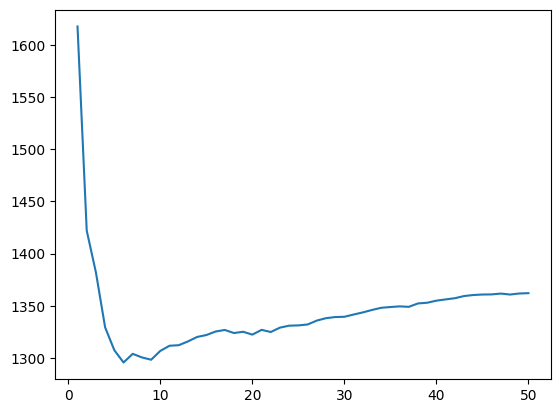

In [ ]:
#Elbow curve
import matplotlib.pyplot as plt
plt.plot(k_list, rmse_val)